### Training a CNN on the "Cats and Dogs" dataset
Before you can download the dataset, you must do the following:

1. Go to https://www.kaggle.com/ and sign in.
2. Go to https://www.kaggle.com/competitions/dogs-vs-cats-redux-kernels-edition/data, scroll down and click to Join the Competition.
3. Go to https://www.kaggle.com/settings and generate a Kaggle API key.
4. Copy the Kaggle API key.
5. Execute the two cells below - and only those two cells. A login dialog is shown. Log in by pasting your Kaggle API key in the text box and clicking the login button.
6. Select the cell below. Then open the Runtime menu and select "Run cell and below". This will run all the remaining cells in the notebook.


In [1]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

In [2]:
# You must log in to kagglehub with your Kaggle API key, before you can download this dataset.

import kagglehub

kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


#### Downloading the data

In [3]:
download_path = kagglehub.competition_download('dogs-vs-cats-redux-kernels-edition')

100%|██████████| 814M/814M [00:06<00:00, 125MB/s]

Extracting files...


In [4]:
import zipfile

with zipfile.ZipFile(download_path + "/train.zip", "r") as zip_ref:
    zip_ref.extractall(".")

In [5]:
import os, shutil, pathlib

original_dir = pathlib.Path("train")
new_base_dir = pathlib.Path("dogs_vs_cats_small")

# This function copies a subset of the original dataset to a folder that you specify as "subset_name".
# The "start_index" and "end_index" arguments specify where to pick the subset in the original dataset.
def make_subset(subset_name, start_index, end_index):
    for category in ("cat", "dog"):
        dir = new_base_dir / subset_name / category
        os.makedirs(dir)
        fnames = [f"{category}.{i}.jpg" for i in range(start_index, end_index)]
        for fname in fnames:
            shutil.copyfile(src=original_dir / fname, dst=dir / fname)

# Use the "make_subset" function to create folders with training, validation and test sets. I will only
# use 10% of the original dataset, since I want to demonstrate the benefits of using data augmentation.
make_subset("train", start_index=0, end_index=1000)
make_subset("validation", start_index=1000, end_index=1500)
make_subset("test", start_index=1500, end_index=2500)

#### Building your model

In [6]:
import keras
from keras import layers

model = keras.models.Sequential([
    keras.Input(shape=(180, 180, 3)),
    layers.Rescaling(1.0 / 255),

    # Data augmentation:
    # Keras data augmentation layers are only applied during training.
    # Such layers can be added when we define the model as shown right below,
    # or they can be added to the training set outside the model.
    # Data augmentation done inside the model will be running on the GPU, if
    # a GPU is used for training. Data augmentation done outnside the model
    # will be running on the CPU. For that reason, I will do data augmentation
    # outside the model (I will do that just before I train the model).
    
#    layers.RandAugment(value_range=(0, 1), num_ops=3, factor=0.5),
#    layers.RandomFlip("horizontal"),
#    layers.RandomRotation(0.1),
#    layers.RandomZoom(0.2),

    layers.Conv2D(filters=32, kernel_size=3, activation="relu"),
    layers.MaxPooling2D(pool_size=2),
    layers.Conv2D(filters=64, kernel_size=3, activation="relu"),
    layers.MaxPooling2D(pool_size=2),
    layers.Conv2D(filters=128, kernel_size=3, activation="relu"),
    layers.MaxPooling2D(pool_size=2),
    layers.Conv2D(filters=256, kernel_size=3, activation="relu"),
    layers.MaxPooling2D(pool_size=2),
    layers.Conv2D(filters=512, kernel_size=3, activation="relu"),
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.25),
    layers.Dense(units=1, activation="sigmoid")
])

In [7]:
model.summary(line_length=80)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)             │ (None, 180, 180, 3)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d (Conv2D)                   │ (None, 178, 178, 32)     │           896 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)      │ (None, 89, 89, 32)       │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)                 │ (None, 87, 87, 64)       │        18,496 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)    │ (None, 43, 43, 64)       │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)                 │ (None, 41, 41, 128)      │        73,856 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)    │ (None, 20, 20, 128)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)                 │ (None, 18, 18, 256)      │       295,168 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)    │ (None, 9, 9, 256)        │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)                 │ (None, 7, 7, 512)        │     1,180,160 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ global_average_pooling2d          │ (None, 512)              │             0 │
│ (GlobalAveragePooling2D)          │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout (Dropout)                 │ (None, 512)              │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense (Dense)                     │ (None, 1)                │           513 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 1,569,089 (5.99 MB)

 Trainable params: 1,569,089 (5.99 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"],
)

#### Data preprocessing
Currently, the data sits on a drive as JPEG files, so the steps for getting it into the model are roughly as follows:

1. Read the picture files.
2. Decode the JPEG content to RGB grids of pixels.
3. Convert these into floating-point tensors.
4. Resize them to a shared size (we’ll use 180 x 180).
5. Pack them into batches (we’ll use batches of 64 images).

Keras has a utility function, called image_dataset_from_directory, which can perform all of the above steps. We will use this function. It will create and return a tf.data.Dataset object configured to read these files, shuffle them, decode them to tensors, resize them to a shared size, and pack them into batches.

In [9]:
from keras.utils import image_dataset_from_directory

batch_size = 64
image_size = (180, 180)
train_dataset = image_dataset_from_directory(
    new_base_dir / "train", image_size=image_size, batch_size=batch_size
)
validation_dataset = image_dataset_from_directory(
    new_base_dir / "validation", image_size=image_size, batch_size=batch_size
)
test_dataset = image_dataset_from_directory(
    new_base_dir / "test", image_size=image_size, batch_size=batch_size
)

Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Found 2000 files belonging to 2 classes.


#### Fitting the model
A tf.data.Dataset object is an iterator: you can use it in a for loop. It will typically return batches of input data and labels. You can pass a Dataset object directly to the fit() method of a Keras model.

In [10]:
for data_batch, labels_batch in train_dataset:
    print("data batch shape:", data_batch.shape)
    print("labels batch shape:", labels_batch.shape)
    break

data batch shape: (64, 180, 180, 3)
labels batch shape: (64,)


In [12]:
# The code in this cell performs data augmentation on the training set.
# Here I use the RandomFlip, RandomRotation and RandomZoom layers. I have
# also tried with the RandAugment layer instead of the before mentioned 3
# layers. It seems that you get slightly better accuracy with RandAugment for
#  most, but not all training experiments. However, this comes with the cost
# of longer training time, and for that reason chose not to use RandAugment.

import tensorflow as tf

# Defines the transformations to apply as a list
data_augmentation_layers = [
#    layers.RandAugment(value_range=(0, 255), num_ops=3, factor=0.5),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2),
]

# Creates a function that applies them sequentially on each image that is
# passed to the function.
def data_augmentation(images, targets):
    for layer in data_augmentation_layers:
        images = layer(images)
    return images, targets

# We use the TensorFlow Dataset function, called map, to perform data
# augmentation on the training set. Since our own "data_augmentation"
# function, defined above, is passed as an argument, the map function
# applies the "data_augmentation" function on each image in the training
# set, and returns an "augmented_train_dataset" containing the
# transformed images.
augmented_train_dataset = train_dataset.map(
    data_augmentation, num_parallel_calls=8
)
# Enables prefetching of batches on GPU memory; important for best
# performance
augmented_train_dataset = augmented_train_dataset.prefetch(tf.data.AUTOTUNE)

In [13]:
# Early stopping
early_stopping = keras.callbacks.EarlyStopping(patience=20, monitor="val_accuracy", restore_best_weights=True)

# Learning rate scheduling
lr_scheduler = keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=10)

history = model.fit(
#    train_dataset,
    augmented_train_dataset,
    epochs=200,
    validation_data=validation_dataset,
    callbacks=[early_stopping, lr_scheduler]
)

Epoch 1/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 34s 539ms/step - accuracy: 0.4805 - loss: 0.7012 - val_accuracy: 0.4990 - val_loss: 0.6931 - learning_rate: 0.0010
Epoch 2/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 421ms/step - accuracy: 0.4995 - loss: 0.6931 - val_accuracy: 0.6030 - val_loss: 0.6927 - learning_rate: 0.0010
Epoch 3/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 432ms/step - accuracy: 0.5390 - loss: 0.6908 - val_accuracy: 0.5320 - val_loss: 0.6810 - learning_rate: 0.0010
Epoch 4/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 20s 415ms/step - accuracy: 0.5530 - loss: 0.6845 - val_accuracy: 0.5850 - val_loss: 0.6816 - learning_rate: 0.0010
Epoch 5/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 15s 452ms/step - accuracy: 0.5605 - loss: 0.6848 - val_accuracy: 0.6060 - val_loss: 0.6632 - learning_rate: 0.0010
Epoch 6/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 428ms/step - accuracy: 0.6025 - loss: 0.6627 - val_accuracy: 0.5290 - val_loss: 0.6892 - learning_rate: 0.0010
Epoch 7/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 431ms/step - accuracy: 0.5940 - l

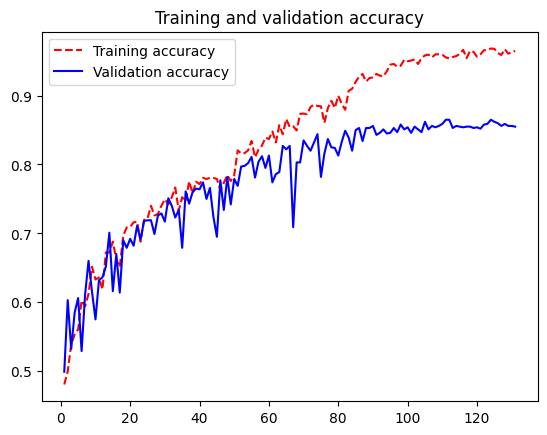

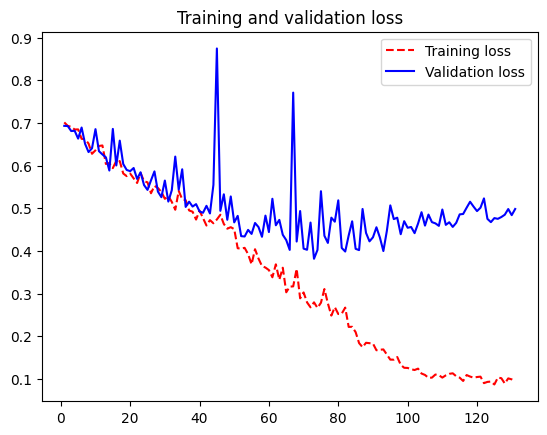

In [14]:
import matplotlib.pyplot as plt

accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(accuracy) + 1)

plt.plot(epochs, accuracy, "r--", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()

plt.plot(epochs, loss, "r--", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

In [15]:
test_loss, test_acc = model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - accuracy: 0.8615 - loss: 0.5342
Test accuracy: 0.862
